# NOTEBOOK NAME
Created by: Thomas Durand-Texte, 2023

# Import des packages et données
## import des packages

In [1]:
import os

import pandas as pd
import numpy as np
# import dask as dd
pd.set_option("display.max_columns", 200)
import datetime as dt
import scipy.stats as st

from statsmodels.multivariate.manova import MANOVA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda

import time

import pickle

from sklearn import model_selection, metrics, preprocessing
from sklearn import cluster

import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

import plotly.express as px

cm = 1./2.54
path_print = 'Figures/simulations/'

## Paramètres graphiques et fonctions utiles

In [2]:
import subprocess

white_font = True
def set_theme(white_font=True):
    """Réglages graphiques

    Args:
        white_font (bool, optional): set if font a set to white (True) or black (False). Defaults to True.
    """
    if white_font: wht, grey, blck = '0.84' , '0.5', 'k'
    else: wht, grey, blck = 'k', '0.5', '0.84'
    rc = { 'figure.facecolor':(0.118,)*3,
            'axes.labelcolor':wht,
            'axes.edgecolor':wht,
            'axes.facecolor':(0,0,0,0),
            'text.color':'white',
            'text.usetex':False,
            'text.latex.preamble':r'\usepackage[cm]{sfmath} \usepackage{amsmath}' ,
            'font.family': 'sans-serif' ,
            'font.sans-serif': 'DejaVu Sans' ,
            'xtick.color':wht,
            'ytick.color':wht,
            "axes.grid" : True,
            "grid.color": (0.7,)*3,
            "grid.linewidth": 0.4,
            "grid.linestyle": (10,5),
            'legend.edgecolor':'0.2',
            'legend.facecolor':(0.2,0.2,0.2,0.6),
            # 'legend.framealpha':'0.6',
            'pdf.fonttype':42,
            'savefig.format':'pdf',
            'savefig.transparent':True,
            'figure.dpi':150, # for better agreemet figsize vs real size
        }

    sns.set_theme('notebook' , rc=rc)
    return


def make_folder(path_folder:str):
    """Create a folder given the path. Test is performed first to check if folder already exists or not.

    Args:
        path_folder (str): path to the folder
    """
    path_folder = path_folder.__str__()
    try:
        if os.path.isdir(path_folder) : return
        os.makedirs(path_folder)
    except OSError:
        pass
    return


def concat_folders(*args, **kwargs)->str:
    """Concatenate strings to form a path to a folder

    exemple concat_filders('/abc', 'ABC') -> '/abc/ABC/'

    Returns:
        str: concatenated string corresponding to a path to a folder
    """
    sPath = ''
    for arg in args:
        if arg == '..': sPath = sPath[:sPath[:-1].rfind(os.sep)+1]
        else: sPath += arg
        if sPath[-1] != os.sep: sPath += os.sep
    return sPath


class Path(object):
    """ Path(s_in='', s_lim=None)
        create a path to the string s_in (default is current path)
        and stops after s_lim """
    n_Path = 0
    def __init__(self, s_in='', s_lim=None):
        """Initialisation of class Path

        Args:
            s_in (str, optional): string corresponding to a folder path. Defaults to '' (current working directory).
            s_lim (_type_, optional): chain to limit the path. Defaults to None. Example s_in = '/folder_1/folder_2/folder_3', s_lim = '2', leads to '/folder_1/folder_2/'
        """
        if s_in == '': s_in = os.getcwd()
        if not s_lim is None:
            if s_lim in s_in:
                s_in = s_in[ :s_in.index(s_lim) + len(s_lim) ]
        self.sPath = concat_folders(s_in)
        self.N = Path.n_Path
        Path.n_Path += 1
        return

    def __add__(self, other):
        """ Path + str : return str """
        if isinstance(other, str): return self.sPath + other

    def __truediv__(self, other):
        """ Path / str : return path concatenated"""
        if isinstance(other, str): return Path(concat_folders(self.sPath, other))

    def __invert__(self):
        """ ~Path : return str of the path """
        return self.sPath

    def __str__(self):
        """ __str__ return str of the path """
        return self.sPath
    # __str__ #

    def makedir(self):
        """ Create a folder from current path if it does not exists """
        return make_folder(self)


def gs_opt(filename:str):
    """otpimisation of a pdf file with gosthscript

    Args:
        filename (str): string corresponding to the pdf file to optimise
    """
    filenameTmp = filename.replace('.pdf', '') + '_tmp.pdf'
    gs = ['gs',
            '-sDEVICE=pdfwrite',
            '-dEmbedAllFonts=true',
            '-dSubsetFonts=true',             # Create font subsets (default)
            '-dPDFSETTINGS=/prepress',        # Image resolution
            '-dDetectDuplicateImages=true',   # Embeds images used multiple times only once
            '-dCompressFonts=true',           # Compress fonts in the output (default)
            '-dNOPAUSE',                      # No pause after each image
            '-dQUIET',                        # Suppress output
            '-dBATCH',                        # Automatically exit
            '-sOutputFile='+filenameTmp,      # Save to temporary output
            filename]                         # Input file

    subprocess.run(gs)                                      # Create temporary file
    subprocess.run('rm -f ' + filename, shell=True)            # Delete input file
    subprocess.run('mv -f ' + filenameTmp + " " + filename, shell=True) # Rename temporary to input file


def savefig(fig, savename:str, **kwargs):
    """Saves a figure with kwargs (fig.savefig(savename, **kwargs)).
       A check is done first to determine if a folder has to be created according to savename.
       Finally, if the file is saved as .pdf, gosthscript optimisation is performed.

    Args:
        fig : matplotlib figure
        savename (str): string of the name of the output pdf file
    """


    if os.sep in savename: make_folder(savename[:savename.rindex(os.sep)])
    fig.savefig(savename, **kwargs)
    savename += '.pdf'
    if os.path.isfile(savename): gs_opt(savename)
    return


def image_size_from_shape(shape: tuple, width: float = None, height: float = None, ymargin=0.):
    """Compute tuple (width, height) from shape tuple of an image an width or height

    Args:
        shape (tuple): shape of the image (n_rows, n_cols)
        width (float, optional): desired width. Defaults to None.
        height (float, optional): desired height. Defaults to None.
        ymargin (_type_, optional): margin added to the output height. Defaults to 0..

    Returns:
        tuple: (width, height)
    """
    if not width is None:
        return width, width*shape[0]/shape[1] + ymargin
    if not heihgt is None:
        return height*shape[1]/shape[0]+xmargin, height
    else:
        print('\n!!! image_size_from_shape: nor width nor heigth was provided !!!\n')
        return shape


set_theme()
del set_theme

## Chargement des données

Affichage de l'arborescence

In [3]:
def print_listdir(path=None, level=0, exclude=[]):
    """Affiche l'arborescence des dossiers et fichiers

    Args:
        path (_type_, optional): chemin du dossier à explorer. Defaults to None.
        level (int, optional): niveau d'indentation. Defaults to 0.
        exclude (list, optional): dossiers = exclure. Defaults to [].
    """
    suffix = ''
    if level > 0:
        suffix = ' |-'* level
    vals = os.listdir(path)
    vals.sort()
    if path is None:
        path = ''
    for val in vals:
        if val in exclude: continue
        print(suffix, val)
        if os.path.isdir(path + val):
            print_listdir(path + val + '/', level+1)

print_listdir(exclude=['.venv', '.venv2', 'Figures', 'diaporama', 'ressources', 'devel'])

 data
 |- cleaned
 |- |- iteration_tsne_RFM.pickle
 |- |- iteration_tsne_RFM_delay.pickle
 |- |- iteration_tsne_RFM_review_score.pickle
 |- |- iteration_tsne_RFM_type_payment.pickle
 |- data_diagram.png
 |- data_diagram_resized.png
 |- source
 |- |- olist_customers_dataset.csv
 |- |- olist_customers_dataset.csv.zip
 |- |- olist_geolocation_dataset.csv
 |- |- olist_geolocation_dataset.csv.zip
 |- |- olist_order_items_dataset.csv
 |- |- olist_order_items_dataset.csv.zip
 |- |- olist_order_payments_dataset.csv
 |- |- olist_order_payments_dataset.csv.zip
 |- |- olist_order_reviews_dataset.csv
 |- |- olist_order_reviews_dataset.csv.zip
 |- |- olist_orders_dataset.csv
 |- |- olist_orders_dataset.csv.zip
 |- |- olist_products_dataset.csv
 |- |- olist_products_dataset.csv.zip
 |- |- olist_sellers_dataset.csv
 |- |- product_category_name_translation.csv
 exploration.ipynb
 install_packages_venv.sh
 install_packages_venv2.sh
 notebook.ipynb
 notebook_essais.ipynb
 notebook_simulation.ipynb
 note

Chargement des données

In [11]:
path = 'data/source/'

filenames = ['customers', 'geolocation', 'orders', 'order_items', 'order_payments', 'order_reviews', 'products', 'sellers']
dfs = {filename: pd.read_csv(path + f'olist_{filename}_dataset' + '.csv') for filename in filenames}
filename = 'product_category_name_translation'
dfs[filename] = pd.read_csv(path + filename + '.csv')

path_save = 'data/cleaned/'

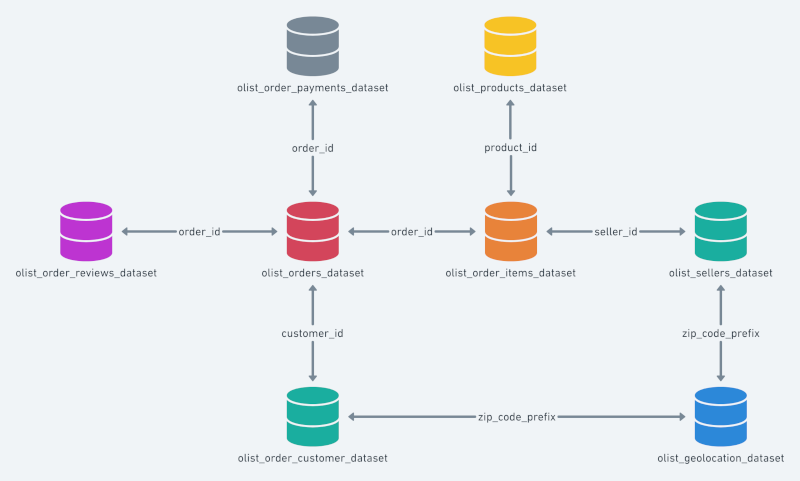

In [12]:
df_merged = dfs['orders'].merge(dfs['customers'], how='left', on='customer_id')
df_merged = df_merged.merge(dfs['order_payments'], how='left', on='order_id')
df_merged = df_merged.merge(dfs['order_reviews'], how='left', on='order_id')

df_merged.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
52462,fe4a38f31cc342320f3aff62e8219a62,91c76805866deab5a543dbc2ebd380aa,delivered,2018-06-19 12:40:04,2018-06-19 12:58:17,2018-06-19 13:26:00,2018-06-22 20:36:36,2018-07-12 00:00:00,c9ef8b7bd9dd304e50342cc162141127,36025,juiz de fora,MG,1.0,credit_card,1.0,108.81,fd71d8ca7e9c2872702256cd808d8915,3.0,Não vieram os parafusos,"Ainda não usei, mas dou 3 estrelas porque não...",2018-06-23 00:00:00,2018-06-26 14:23:52
20735,dfc6c80c73f6b324371273bd97e19c3f,02b20345e0df036b3078abd5b381b241,delivered,2017-06-04 12:09:58,2017-06-04 13:02:13,2017-06-07 12:16:35,2017-06-08 14:12:57,2017-06-19 00:00:00,382ad79426068e4ba6ed73491d4441cb,13310,itu,SP,1.0,credit_card,2.0,24.08,258dc67e9f3802ef26a0ac367bbd8159,5.0,NaN,NaN,2017-06-14 00:00:00,2017-06-15 23:21:05
25680,db274d549125d73b0e1052886af9422e,4438ad15cf7315f2de20eebdb7b12840,delivered,2018-07-23 22:35:59,2018-07-24 10:31:07,2018-07-26 07:22:00,2018-07-27 20:41:49,2018-08-03 00:00:00,79a0b307b44974216a780af39a34ff31,4661,sao paulo,SP,1.0,credit_card,3.0,85.75,6d7ff6f2dddc178a8a632ba14b24c1d3,3.0,NaN,NaN,2018-07-28 00:00:00,2018-07-29 00:42:57
90333,c921b31250ffb9719326413202688113,012e0c27bbc549e7c249ee9042d58f7b,delivered,2018-05-07 13:37:30,2018-05-07 15:33:06,2018-05-09 15:14:00,2018-05-21 13:14:32,2018-06-05 00:00:00,7fb58ee27f8074e833967c1d607d4452,41750,salvador,BA,1.0,credit_card,3.0,232.88,a20bc4efbe8113baaed9990e291c1aea,1.0,Cozinha turma da Mônica,Comprei a cozinha da turma da Mônica e foi ent...,2018-05-22 00:00:00,2018-05-24 01:13:34
27924,a2621d414c9c28d85816bbc9f2e8980d,8a7ea5641aa689d62643a0519501dc39,unavailable,2017-09-22 15:42:18,2017-09-22 15:50:15,NaN,NaN,2017-10-19 00:00:00,d4b2193f58a874bcfb2352407869ddf9,36900,manhuacu,MG,1.0,credit_card,9.0,90.26,32024659636af2d0612208d532cb1b7e,1.0,NaN,NaN,2017-10-21 00:00:00,2017-10-21 12:20:47


In [13]:
timestamp_cols = ['order_purchase_timestamp', 'order_approved_at',
                  'order_delivered_carrier_date', 'order_delivered_customer_date',
                  'order_estimated_delivery_date'
                 ]
for col in timestamp_cols:
    df_merged[col] = pd.to_datetime(df_merged[col])

In [14]:
loc = df_merged['order_status'] == 'delivered'

key = 'delivery_time'
df_merged[key] = np.nan
df_merged.loc[loc, key] = df_merged.loc[loc, 'order_delivered_customer_date'] - df_merged.loc[loc, 'order_purchase_timestamp']

key = 'estimated_delivery_time'
df_merged[key] = np.nan
df_merged.loc[loc, key] = df_merged.loc[loc, 'order_estimated_delivery_date'] - df_merged.loc[loc, 'order_purchase_timestamp']

# DELIVRY DELAY, EXPRESSED IN HOURS
key = 'delivery_delay'
df_merged[key] = np.nan
delay = df_merged.loc[loc, 'delivery_time'] - df_merged.loc[loc, 'estimated_delivery_time']
df_merged.loc[loc, key] = 24*delay.dt.days + delay.dt.seconds/3600

df_merged.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_time,estimated_delivery_time,delivery_delay
39465,658bea3a595af733d395a91ed9714160,795b7ae8e06558aae3a68ce5c74ee36a,delivered,2017-11-23 17:28:29,2017-11-23 18:25:02,2017-11-25 02:41:18,2017-12-01 19:06:37,2017-12-22,43fe8dd64f7a6328782c63d08e4d00e6,70843,brasilia,DF,1.0,credit_card,2.0,501.44,1a06ec45ca797c5286b11d65657f24ad,5.0,NaN,NaN,2017-12-02 00:00:00,2017-12-02 21:35:58,8 days 01:38:08,28 days 06:31:31,-484.889722
7174,623d9c7205ead428a68b210b93e69148,7d7fc89ea76913eeb562675ed70cb77f,delivered,2018-03-19 09:34:03,2018-03-20 03:35:47,2018-03-21 21:27:47,2018-03-24 18:08:32,2018-03-29,6df2dbb5ec4a3c72ffc716d264b4b425,13326,salto,SP,1.0,boleto,1.0,26.29,018d165c539f3d2a2e5af62198772034,5.0,NaN,NaN,2018-03-25 00:00:00,2018-03-26 14:43:57,5 days 08:34:29,9 days 14:25:57,-101.857778
43601,2e9d2850537d9e6975149a266b9ecf69,398634ab2ca4bee203cd25ea737a49a8,delivered,2018-07-30 21:07:34,2018-07-30 21:24:32,2018-08-06 14:22:00,2018-08-09 02:26:34,2018-08-06,c602b245df5ba83a335cc0145581ced8,5417,sao paulo,SP,1.0,credit_card,1.0,118.35,32f86fab63f2af46d3ee7fffae3acd29,5.0,NaN,NaN,2018-08-08 00:00:00,2018-08-10 09:58:35,9 days 05:19:00,6 days 02:52:26,74.442778
16967,73deceb3150fdc9ade84ac49e7bbcb85,2fa2ceab7ce768b8a12761aad46f935a,delivered,2017-05-04 12:21:29,2017-05-05 06:35:20,2017-05-10 09:17:50,2017-05-11 07:25:46,2017-06-05,c4897179d57e050171896bd35f4b64a5,88058,florianopolis,SC,1.0,boleto,1.0,95.22,5ec611ae10587c9a58562f9a5de0bc74,5.0,NaN,NaN,2017-05-12 00:00:00,2017-05-14 17:35:17,6 days 19:04:17,31 days 11:38:31,-592.570556
39531,ad6b07be756ec7284a64503ac34f6975,e34f1deeea3369207caab9fd7a49cee8,delivered,2017-04-05 15:04:14,2017-04-07 03:11:01,2017-04-10 15:50:46,2017-04-19 16:49:07,2017-05-09,8e0eae873c0019e01182099a1c497b79,96810,santa cruz do sul,RS,1.0,boleto,1.0,723.48,23858b806b4f44681dec4e5b24357914,5.0,NaN,NaN,2017-04-20 00:00:00,2017-04-25 20:49:49,14 days 01:44:53,33 days 08:55:46,-463.181389
102995,6c9296925051cae6d38b3678754b678f,12be52e43688a69df1a944757b37a6cf,delivered,2017-08-18 13:49:25,2017-08-18 14:05:33,2017-08-18 19:52:15,2017-08-26 12:51:24,2017-09-08,3d3bf9b46e016ce49985d11d21854aa1,31640,belo horizonte,MG,1.0,credit_card,1.0,72.33,6dbf65d9b46e7350902f98ae7aa6c10b,4.0,NaN,NaN,2017-08-27 00:00:00,2017-08-30 10:49:00,7 days 23:01:59,20 days 10:10:35,-299.143333
44738,1cce7dd1eeb53ad0f97744d159ca50a2,a7ac1b6c1a757603893d9cd450380da7,delivered,2017-02-14 08:14:47,2017-02-14 08:25:18,2017-02-14 10:31:59,2017-02-20 11:41:26,2017-03-15,fb737b990b5facd01230b6708a067143,30180,belo horizonte,MG,2.0,voucher,1.0,207.45,46a28114252fcc7992747acf6a933b02,5.0,NaN,NaN,2017-02-21 00:00:00,2017-02-22 02:43:10,6 days 03:26:39,28 days 15:45:13,-540.309444
7167,d32e51406daab72e2dceefb08b096e13,7139a35b7933e0fb709bb8b33a28e408,delivered,2018-07-03 13:39:25,2018-07-05 16:26:40,2018-07-04 11:36:00,2018-07-13 14:08:44,2018-08-06,9c4e9cdeb7afe29d1395506e385c468b,78455,lucas do rio verde,MT,1.0,credit_card,8.0,160.05,cea9f285260dcf38ceba1436f95052f7,5.0,NaN,NaN,2018-07-14 00:00:00,2018-07-16 12:21:34,10 days 00:29:19,33 days 10:20:35,-561.854444
59404,46adacfb7a94e068dc59aee8c57cae9d,f72e6726c968412453cd6d21629572cc,delivered,2018-04-18 04:37:35,2018-04-18 07:31:50,2018-04-19 00:28:49,2018-04-20 00:46:35,2018-04-30,996bf61e02442534789e96e4628b5754,12240,sao jose dos campos,SP,1.0,credit_card,1.0,113.22,c1a929f2a1f58a9d3acaa05786b5587a,5.0,NaN,NaN,2018-04-20 00:00:00,2018-04-22 20:22:45,1 days 20:09:00,11 days 19:22:25,-239.223611
38846,7198e283e4a0c1146dcc3f5bedd276c2,601d0b60b2b201e4863fc5c248c47655,delivere

In [15]:
groups = df_merged[['customer_unique_id',
                    'payment_value',
                    'delivery_delay'
                   ]].copy()
groups['number_of_days_since_last_order'] = (df_merged['order_purchase_timestamp'].max()
                                             - df_merged['order_purchase_timestamp']
                                            ).dt.days

groups = groups.groupby(by='customer_unique_id')


df_model = groups.agg({'number_of_days_since_last_order':'max',
                        'customer_unique_id':'count',
                        'payment_value':'sum',
                        'delivery_delay':'sum'
                       })

df_model.rename(columns={'number_of_days_since_last_order':'Récence',
                         'customer_unique_id':'Fréquence',
                         'payment_value':'Montant'
                        }, inplace=True)

df_model['delivery_delay'] -= df_model['delivery_delay'].min()

features = df_model.columns

display(df_model.head(5))
print('Number of NaN in the new variable:', df_model['delivery_delay'].isna().sum())

,Recence,Frequence,Montant,delivery_delay
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,15139.610278
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,15136.845000
0000f46a3911fa3c0805444483337064,585,1,86.22,15205.446389
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,14972.184722
0004aac84e0df4da2b147fca70cf8255,336,1,196.89,15069.948889


Number of NaN in the new variable: 0


# Fonctions utiles

In [16]:
def describe_clusters_centers(model, scaler, features, labels, title, sort_order=None):
    """Calcul et affichage du centre des clusters

    Args:
        model : modèle entrainé avec le membre cluster_centers_
        scaler : scaler utilisé pour mettre à l'échelle les données
        features (list): list des features
        labels : labels associés aux données
        title : titre utilisé pour l'affichage
        sort_order (list, optional): list d'indices utilisé pour arranger les lignes du DataFrame construit. Defaults to None.
    """
    path_print_tmp = path_print + title.replace(' ', '_') + '/'
    df_clusters = pd.DataFrame(scaler.inverse_transform(model.cluster_centers_), columns=features)

    # labels = model.predict(X_scaled)
    unique, counts = np.unique(labels, return_counts=True)

    df_clusters.loc[unique, 'count'] = counts
    df_clusters['count'] = df_clusters['count'].astype(int)
    df_clusters['count (%)'] = df_clusters['count'] * (100 / df_clusters['count'].sum())
    # df_clusters.info()
    if sort_order is None:
        sort_order = df_clusters.index
        # display(df_clusters.round(2))

    tmp = df_clusters.loc[sort_order,:].round(2)

    df_ltx = tmp.copy() # to be saved below

    tmp = tmp.style.set_caption(title)
    display(tmp)

    tmp = df_clusters.drop(columns=['count (%)', 'count'])
    # normalisation for radar
    max_values = tmp.max(0).values.reshape(1,-1)
    min_values = tmp.min(0).values.reshape(1,-1)
    tmp.loc[:,:] = (tmp.values - min_values) / (max_values-min_values)
    tmp['Recence'] = 1 - tmp['Recence']
    tmp['Recence'] /= tmp['Recence'].max()
    tmp = 1 + 4*tmp

    fig, ax = plt.subplots(figsize=(5,5), subplot_kw={'projection':'polar'})
    fig.suptitle(title)
    ax.grid(True)
    categs = tmp.columns
    theta = np.linspace(0, 2*np.pi, len(categs), endpoint=False)
    ax.set_xticks(theta)
    ax.set_xticklabels(categs)
    ax.set_yticklabels([])
    # import plotly.graph_objects as go
    # fig = go.Figure()
    # display(tmp)
    markersizes = np.linspace(10, 5, len(tmp.index))
    j = 0
    for i in tmp.index:
        # fig.add_trace(go.Scatterpolar(
        #     r=tmp.iloc[i,:].values,
        #     theta=tmp.columns,
        #     name=f'group {i}'
        #    ))
        # print('i', i, 'values', tmp.loc[i,:].values)
        ax.plot(theta, tmp.loc[i,:].values, 'o-', label=f'group {i}', markersize=markersizes[j])
        j += 1
    fig.legend()
    fig.tight_layout()

    savefig(fig, path_print_tmp + 'polar_centers') # create folder and save plot
    with open(path_print_tmp + 'ltx_DataFrame_centers', 'w') as file:
        file.write(df2ltx(df_ltx))


def analyse_results(X, labels, features, path_print=None) :
    """Fonction pour tracer différents graphiques d'analyse des résultats

    Args:
        X (ndarray): données d'entrée non mises à l'échelle
        labels (array like): labels associés aux données X
        features (list): liste du nom des features
        path_print (str, optional): chemin pour enregistrer les figures. Defaults to None (figures non sauvegardées).
    """
    inds = {label: labels==label for label in np.unique(labels)}
    # for label in np.unique(labels):
    #     Xtmp = X[inds[label]]
    #     # Analyse univariée pour chaque variable
    #     fig, axs = plt.subplots(figsize=(5,5), nrows=X.shape[1])
    #     for i, feat in enumerate(features):
    #         axs[i].hist(Xtmp[:,i], bins=30)
    #         axs[i].set_xlabel(feat)
    #     fig.suptitle(f'cluser {label}: {Xtmp.shape[0]} members ({Xtmp.shape[0]/X.shape[0]:.2%})')
    #     fig.tight_layout()

    print('\n\n|' + 40*'-' + '|')
    print(f"{f'{len(inds)} labels' :^42}" + '\n')

    fig, ax = plt.subplots(figsize=(10*cm,10*cm))
    pd.Series({label: values.sum() for label,values in inds.items()}).plot(kind='pie' , ax=ax, autopct='%.1f%%')
    ax.set_title('groups count (%)')
    fig.tight_layout()
    if not path_print is None:
        savefig(fig, path_print + 'pie')

    # dataframe with category
    df = pd.DataFrame(X, columns=features)
    df['cluster'] = labels
    df['cluster'] = df['cluster'].astype('category')

    # MANOVA
    varkeys = df.columns.tolist()[:-1]
    fit = MANOVA.from_formula(' + '.join(varkeys) + ' ~ cluster', data=df)
    print(fit.mv_test())

    X2 = df[varkeys]
    y = df['cluster']
    post_hoc = lda().fit(X=X2, y=y)
    print('\nVARKEYS:', varkeys, '\nX2:', X2.shape)
    print('transform:', post_hoc.transform(X2).shape)

    # get Prior probabilities of groups:
    # post_hoc.priors_

    # get group means
    # post_hoc.means_

    # get Coefficients of linear discriminants
    # post_hoc.scalings_

    # get Proportion of trace (variance explained by each of the selected components)
    # post_hoc.explained_variance_ratio_

    X_new = post_hoc.transform(X2)
    X_new = pd.DataFrame(X_new, columns=[f"lda{i+1}" for i in range(X_new.shape[1])])
    X_new["cluster"] = df["cluster"]

    g = sns.pairplot(X_new, vars=['lda1', 'lda2', 'lda3'], hue='cluster',corner=True, plot_kws={'s':3})
    g.fig.suptitle('Linear Discriminant Analysis')
    g.fig.tight_layout()
    if not path_print is None:
        g.fig.savefig(path_print + 'LDA.png')

    # df.hist(column='Frequence', by='cluster', bins=30, legend=True)

    # * RECENCE
    i = 0
    fig, ax = plt.subplots(figsize=(7,3))
    # ax.hist([X[inds[label],0] for label in inds.keys()], label=list(inds.keys()) , density=True)
    df.groupby('cluster')[features[i]].plot(kind='density')
    ax.legend()
    ax.set_xlabel(features[i])
    fig.tight_layout()
    if not path_print is None:
        savefig(fig, path_print + 'Recence')

    # * FREQUENCE
    i = 1
    # labels_freq = ['']
    # data_histo_Frequence = [np.array([])]
    # for label in inds.keys():
    #     tmp = X[inds[label], i]
    #     if (tmp < 2.5).sum() == tmp.size:
    #         data_histo_Frequence[0] = np.concatenate((data_histo_Frequence[0], tmp))
    #         labels_freq[0] += f'-{label}'
    #         continue
    #     data_histo_Frequence.append(tmp)
    #     labels_freq.append(f'{label}')
    # labels_freq[0] = labels_freq[0][1:] # remove first -

    fig, ax = plt.subplots(figsize=(7,3))
    # ax.hist(data_histo_Frequence, label=labels_freq, bins=np.arange(0.5, 0.5+df['Frequence'].max()))
    # hists = []
    bins = np.arange(0.5, 0.5+df['Frequence'].max())
    for label in inds.keys():
        hist, _ = np.histogram(X[inds[label], i], bins)
        # hists.append(hist)
        if label == 0 :
            markersize=10
        else:
            markersize=7
        ax.plot(bins[1:]+0.5, hist, 'o-', label=label, markersize=markersize)
    # df.groupby('cluster')[features[i]].plot(kind='hist', bins=np.arange(0.5, 0.5+df['Frequence'].max()))
    ax.set_yscale('log')
    ax.set_xlabel(features[i])
    lgd = ax.legend()
    for text in lgd.get_texts():
        ii = int(text.get_text())
        ratio = inds[ii].sum() / X.shape[0]
        text.set_text(f'{ii}: {ratio:.2%}')
    # display(lgd_texts[0].get_text())
    fig.tight_layout()
    if not path_print is None:
        savefig(fig, path_print + 'Frequence')

    # * MONTANT
    i = 2
    fig, ax = plt.subplots(figsize=(7,3))
    # ax.hist([X[inds[label],0] for label in inds.keys()], label=list(inds.keys()) , density=True)
    df.groupby('cluster')[features[i]].plot(kind='density')
    ax.legend()
    ax.set_xlabel(features[i])
    ax.set_xlim([1, ax.get_xlim()[1]])
    ax.set_xscale('log')
    fig.tight_layout()
    if not path_print is None:
        savefig(fig, path_print + 'Montant')

    g = sns.pairplot(df, vars=features, hue='cluster',corner=True, plot_kws={'s':3})
    # g.axes[1,1].set_yscale('log')
    # g.axes[2,1].set_xscale('log')
    g.axes[2,0].set_yscale('log')
    g.axes[2,2].set_xscale('log')
    g.axes[2,2].set_xticks([1, 10, 100, 1000])
    g.axes[2,2].grid(which='both', color='w')
    g.axes[2,2].set_xlim([9, 1000 + 1000*int(df['Montant'].max() // 1000)])
    g.axes[2,0].set_ylim([9, 1000 + 1000*int(df['Montant'].max() // 1000)])
    # g = sns.PairGrid(df, vars=features, hue='cluster',corner=True)
    # g.map_diag(plt.hist)
    # g.map_lower(sns.scatterplot, s=6)
    g.fig.suptitle('Pair Plot initial features')
    g.fig.tight_layout()
    if not path_print is None:
        # savefig(g.fig, path_print + 'pairplot') # too heavy for pdf
        g.fig.savefig(path_print + 'pairplot.png')
    return

# Contrat de maintenance

In [22]:
def extract_data(df, date_init, timespan):
    """Extraction des données comprises entre date_init et date_init + timespan

    Args:
        df (DataFrame): données d'entrée
        date_init (Timestamp): date de début de période
        timespan (Timesdelta): durée de la période

    Returns:
        out (DataFrame): données de sortie
    """
    loc = (df['order_purchase_timestamp'] >= date_init) & (df['order_purchase_timestamp'] < (date_init+timespan))
    tmp = df.loc[loc,:]
    out = tmp[ ['customer_unique_id',
                'payment_value',
                'delivery_delay',      
               ] ].copy()
    out['number_of_days_since_last_order'] = ((date_init+timespan) - tmp['order_purchase_timestamp']).dt.days
    out = out.groupby(by='customer_unique_id')
    out = out.agg({'number_of_days_since_last_order':'max',
                   'customer_unique_id':'count',
                   'payment_value':'sum',
                   'delivery_delay':'sum'
                  })

    out.rename(columns={'number_of_days_since_last_order':'Recence',
                        'customer_unique_id':'Frequence',
                        'payment_value':'Montant'
                        }, inplace=True)

    return out


def compute_ARI_full(df, t0, timespan, timeshift, k):
    """Calcul et affichage de la courbe du ARI score

    Args:
        df (DataFrame): données d'entrée
        t0 (Timestamp): date de début de période
        timespan (Timedelta): durée de la période
        timeshift (Timedelta): pas entre deux points de la courbe
        k (int): nombre de clusters
    """
    df0 = extract_data(df, t0, timespan)
    scaler0 = preprocessing.StandardScaler()
    M0 = cluster.KMeans(k, n_init=1, init='k-means++', random_state=5)
    L0 = M0.fit_predict(scaler0.fit_transform(df0.values))

    # chemin pour sauvegarder les graphiques
    tmp = path_print + f'k_{k}/'

    # description du modèle initial
    describe_clusters_centers(M0, scaler0, df0.columns, L0, f'k means initial (k={k})')
    analyse_results(df0.values, L0, df0.columns, path_print=tmp)

    t_max = df['order_purchase_timestamp'].max()
    print('max order purchase:', t_max, '\n')

    ari_values = []
    time_deltas = []
    ti = t0
    while True:
        ti += timeshift
        if (ti + timespan) > t_max:
            break
        # PRINT CURRENT TI TO FOLLOW PROGRESS
        print('ti:', ti, end='\r')
        # GET DATA
        dfi = extract_data(df, ti, timespan)

        # PREDICTION WITH INITIAL MODEL
        Li0 = M0.predict(scaler0.transform(dfi.values))

        # NEW MODEL
        scaler_i = preprocessing.StandardScaler()
        Mi = cluster.KMeans(k, n_init=1, init='k-means++', random_state=5)
        Xi_scaled = scaler_i.fit_transform(dfi.values)
        Li = Mi.fit_predict(Xi_scaled)
        # Li = Mi.predict(Xi_scaled)

        # CALCUL ARI SCORE
        score = metrics.adjusted_rand_score(Li0, Li)

        # STORE DATA
        ari_values.append(score)
        time_deltas.append((ti-t0).days/7)
    ari_values = np.array(ari_values)
    time_deltas = np.array(time_deltas)
    print('')

    plot_ARI(tmp, time_deltas, ari_values)
    return


def plot_ARI(path_print, time_deltas, ari_values):
    """Affichage de la courbe du score ARI

    Args:
        path_print (str): chemin pour 
        time_deltas (list(Timedelta)): liste des TimeDelta correspondant aux ari_values
        ari_values (list(float)): liste des valeurs du score ARI
    """
    fig, ax = plt.subplots(figsize=(7,3))
    ax.plot(time_deltas, ari_values, '-o')
    ax.set_xlabel('time shift (week)')
    ax.set_ylabel('ARI score')
    ax.set_ylim(ax.get_ylim())

    # ligne de première valeur ari < 0.8
    color = 'y'
    i_lim = np.arange(ari_values.size)[(ari_values < 0.8)][0]
    ax.plot(time_deltas[i_lim], ari_values[i_lim], color + 'o')
    ax.vlines(time_deltas[i_lim], 0.32, 0.96, color=color, linestyles='--')
    _ = ax.annotate(f'{ari_values[i_lim]:.2f} at {int(time_deltas[i_lim])} weeks', [time_deltas[i_lim]+1.3, 0.91], va='bottom', ha='left', color=color)

    # deuxième ligne de valeur ari < 0.8 après que ari soit repassé > 0.8
    color = 'r'
    i = 1
    indices = np.arange(ari_values.size)[(ari_values < 0.8)]
    while i < ari_values.size:
        i_lim = indices[i]
        if (i_lim - indices[i-1]) > 1:
            break
        i += 1

    ax.plot(time_deltas[i_lim], ari_values[i_lim], color + 'o')
    ax.vlines(time_deltas[i_lim], 0.32, 0.87, color=color, linestyles='--')

    _ = ax.annotate(f'{ari_values[i_lim]:.2f} at {int(time_deltas[i_lim])} weeks', [time_deltas[i_lim]+1.3, 0.81], va='bottom', ha='left', color=color)

    fig.tight_layout()
    savefig(fig, path_print + 'ARI')
    return

t0 = pd.Timestamp('2017-01-01 00:00:00')
timespan = pd.Timedelta('365d')
timeshift = pd.Timedelta('7d')

print('t0:', t0)
print('t1:', t0 + timespan)

t0: 2017-01-01 00:00:00
t1: 2018-01-01 00:00:00


## k = 5

,Recence,Frequence,Montant,delivery_delay,count,count (%)
0,235.270000,1.010000,134.900000,-320.290000,16885,38.630000
1,144.990000,1.120000,1264.050000,-278.570000,1030,2.360000
2,67.520000,1.020000,137.960000,-224.850000,23806,54.460000
3,188.800000,14.510000,235.230000,-3920.950000,35,0.080000
4,163.740000,2.480000,214.410000,-870.980000,1957,4.480000




|----------------------------------------|
                 5 labels                 

                     Multivariate linear model
                                                                    
--------------------------------------------------------------------
       Intercept         Value  Num DF   Den DF     F Value   Pr > F
--------------------------------------------------------------------
          Wilks' lambda  0.0776 4.0000 43705.0000 129926.3605 0.0000
         Pillai's trace  0.9224 4.0000 43705.0000 129926.3605 0.0000
 Hotelling-Lawley trace 11.8912 4.0000 43705.0000 129926.3605 0.0000
    Roy's greatest root 11.8912 4.0000 43705.0000 129926.3605 0.0000
--------------------------------------------------------------------
                                                                    
--------------------------------------------------------------------
        cluster         Value   Num DF    Den DF    F Value   Pr > F
------------------------------------

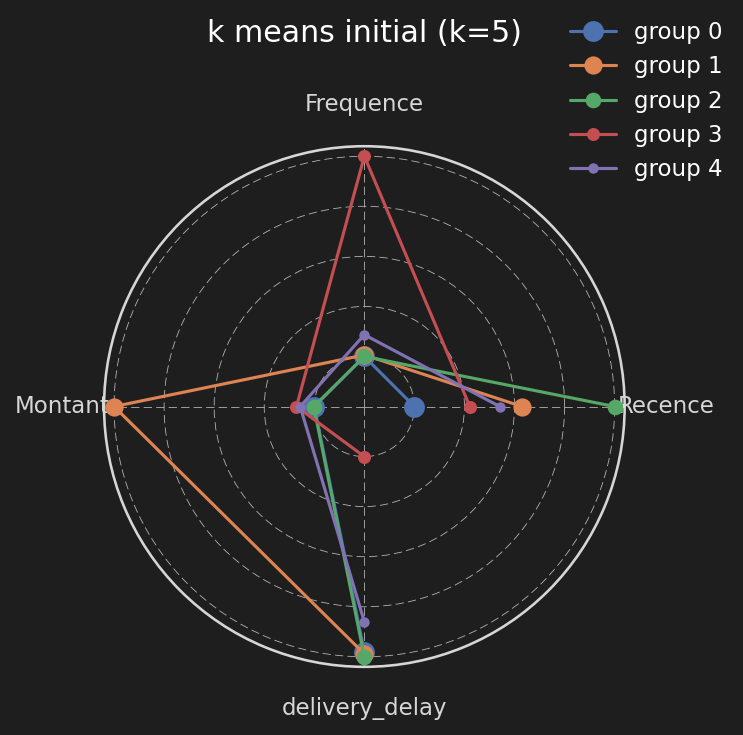

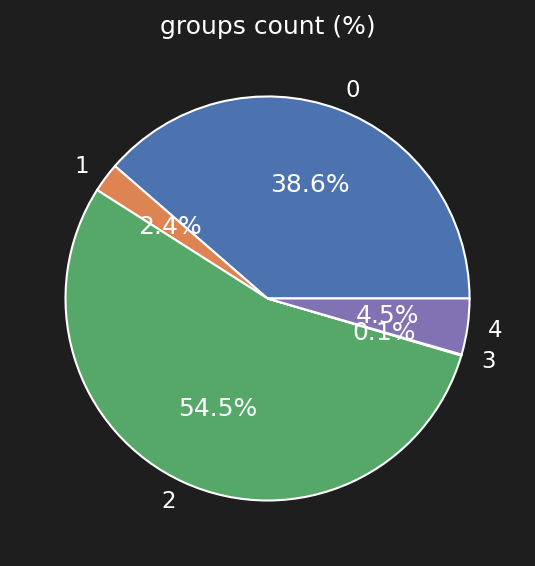

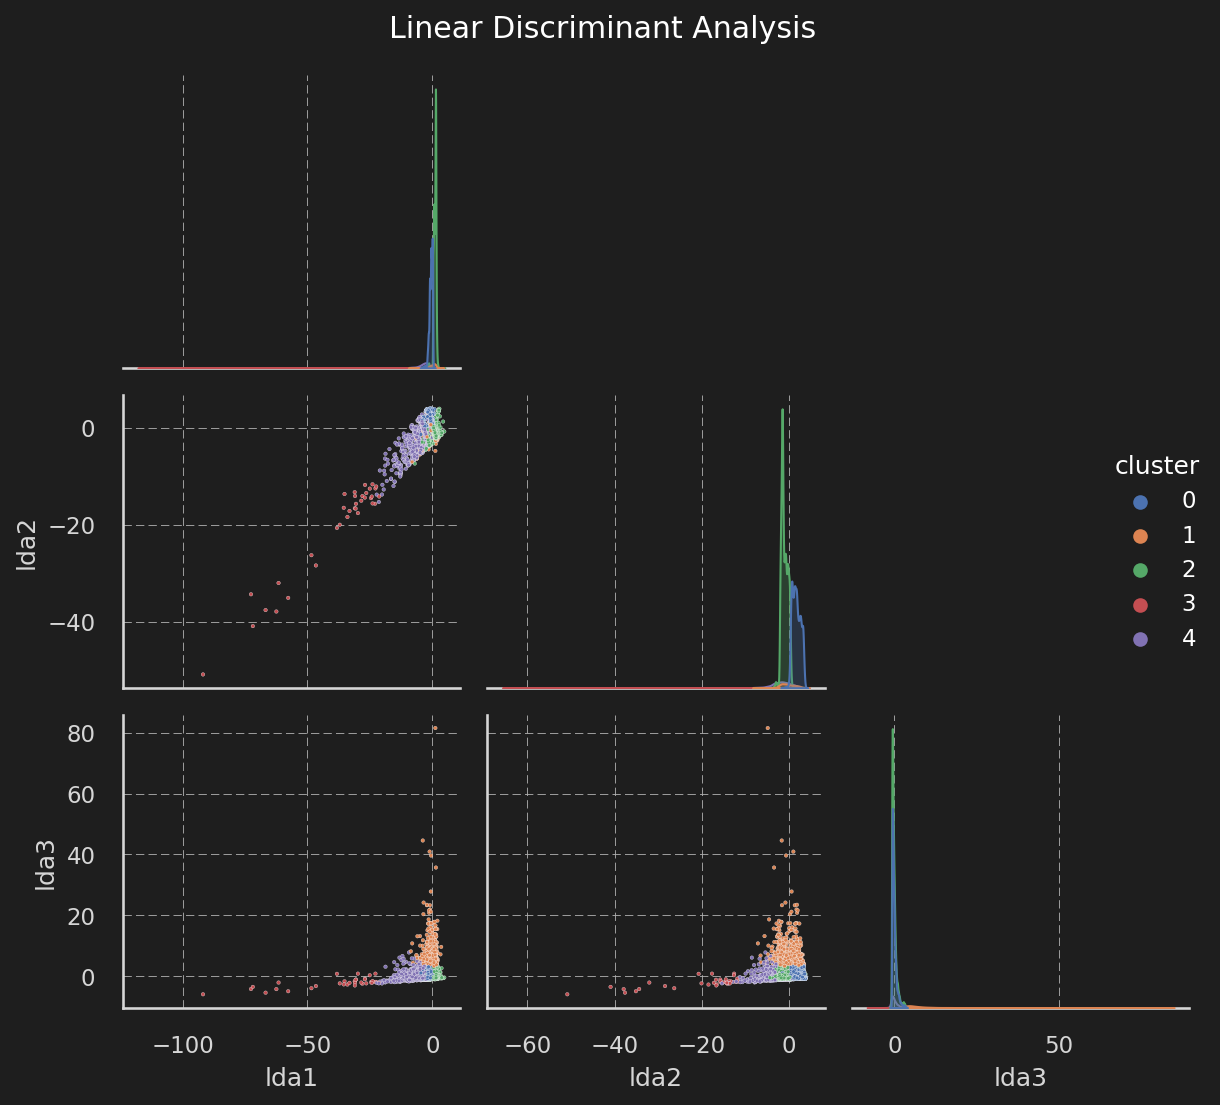

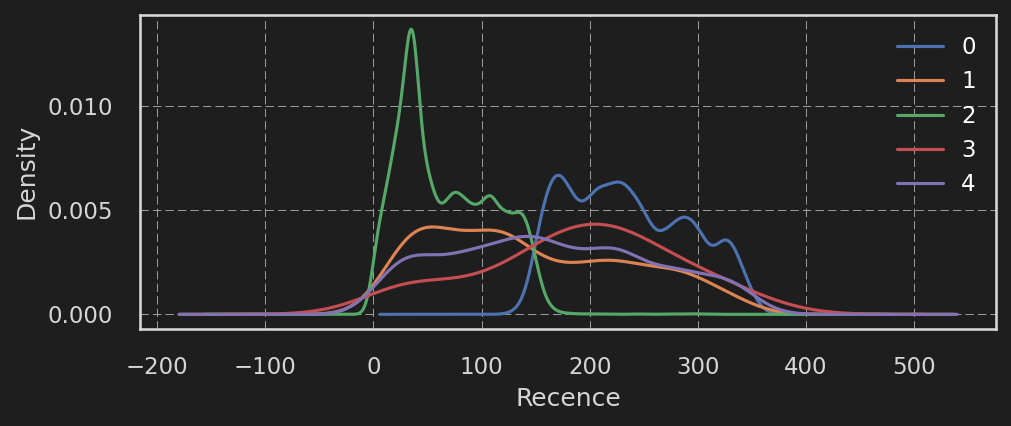

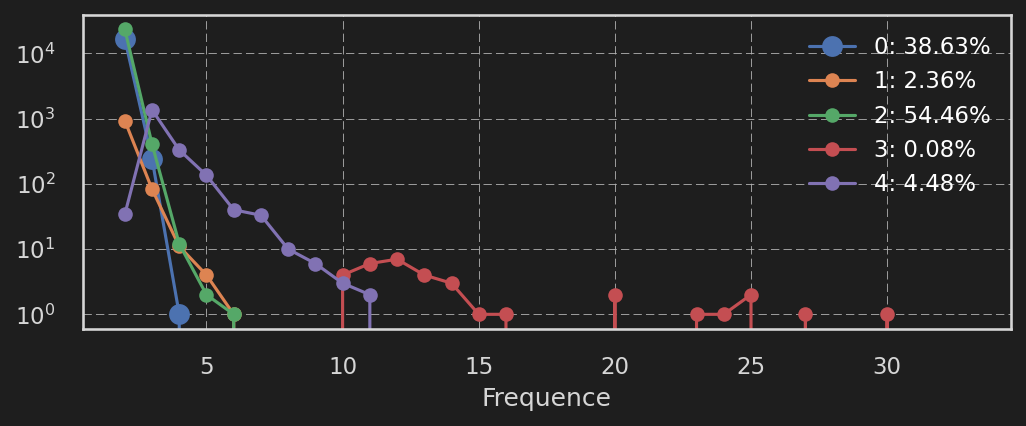

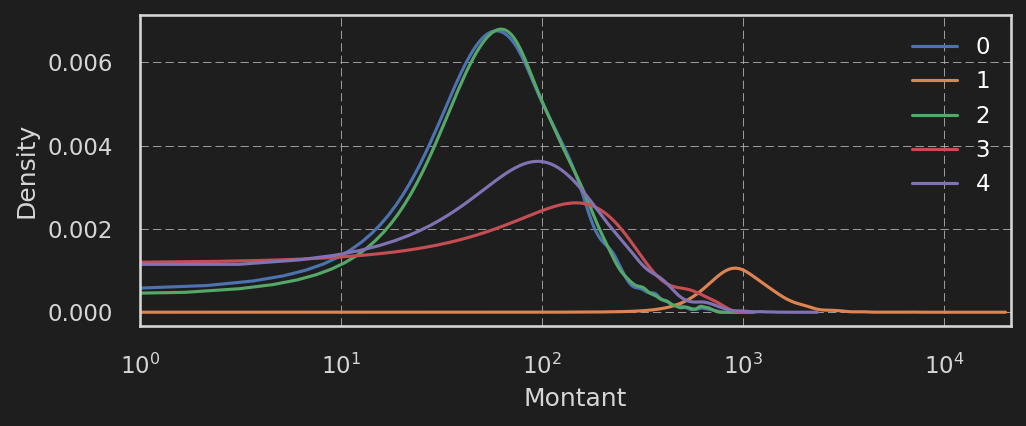

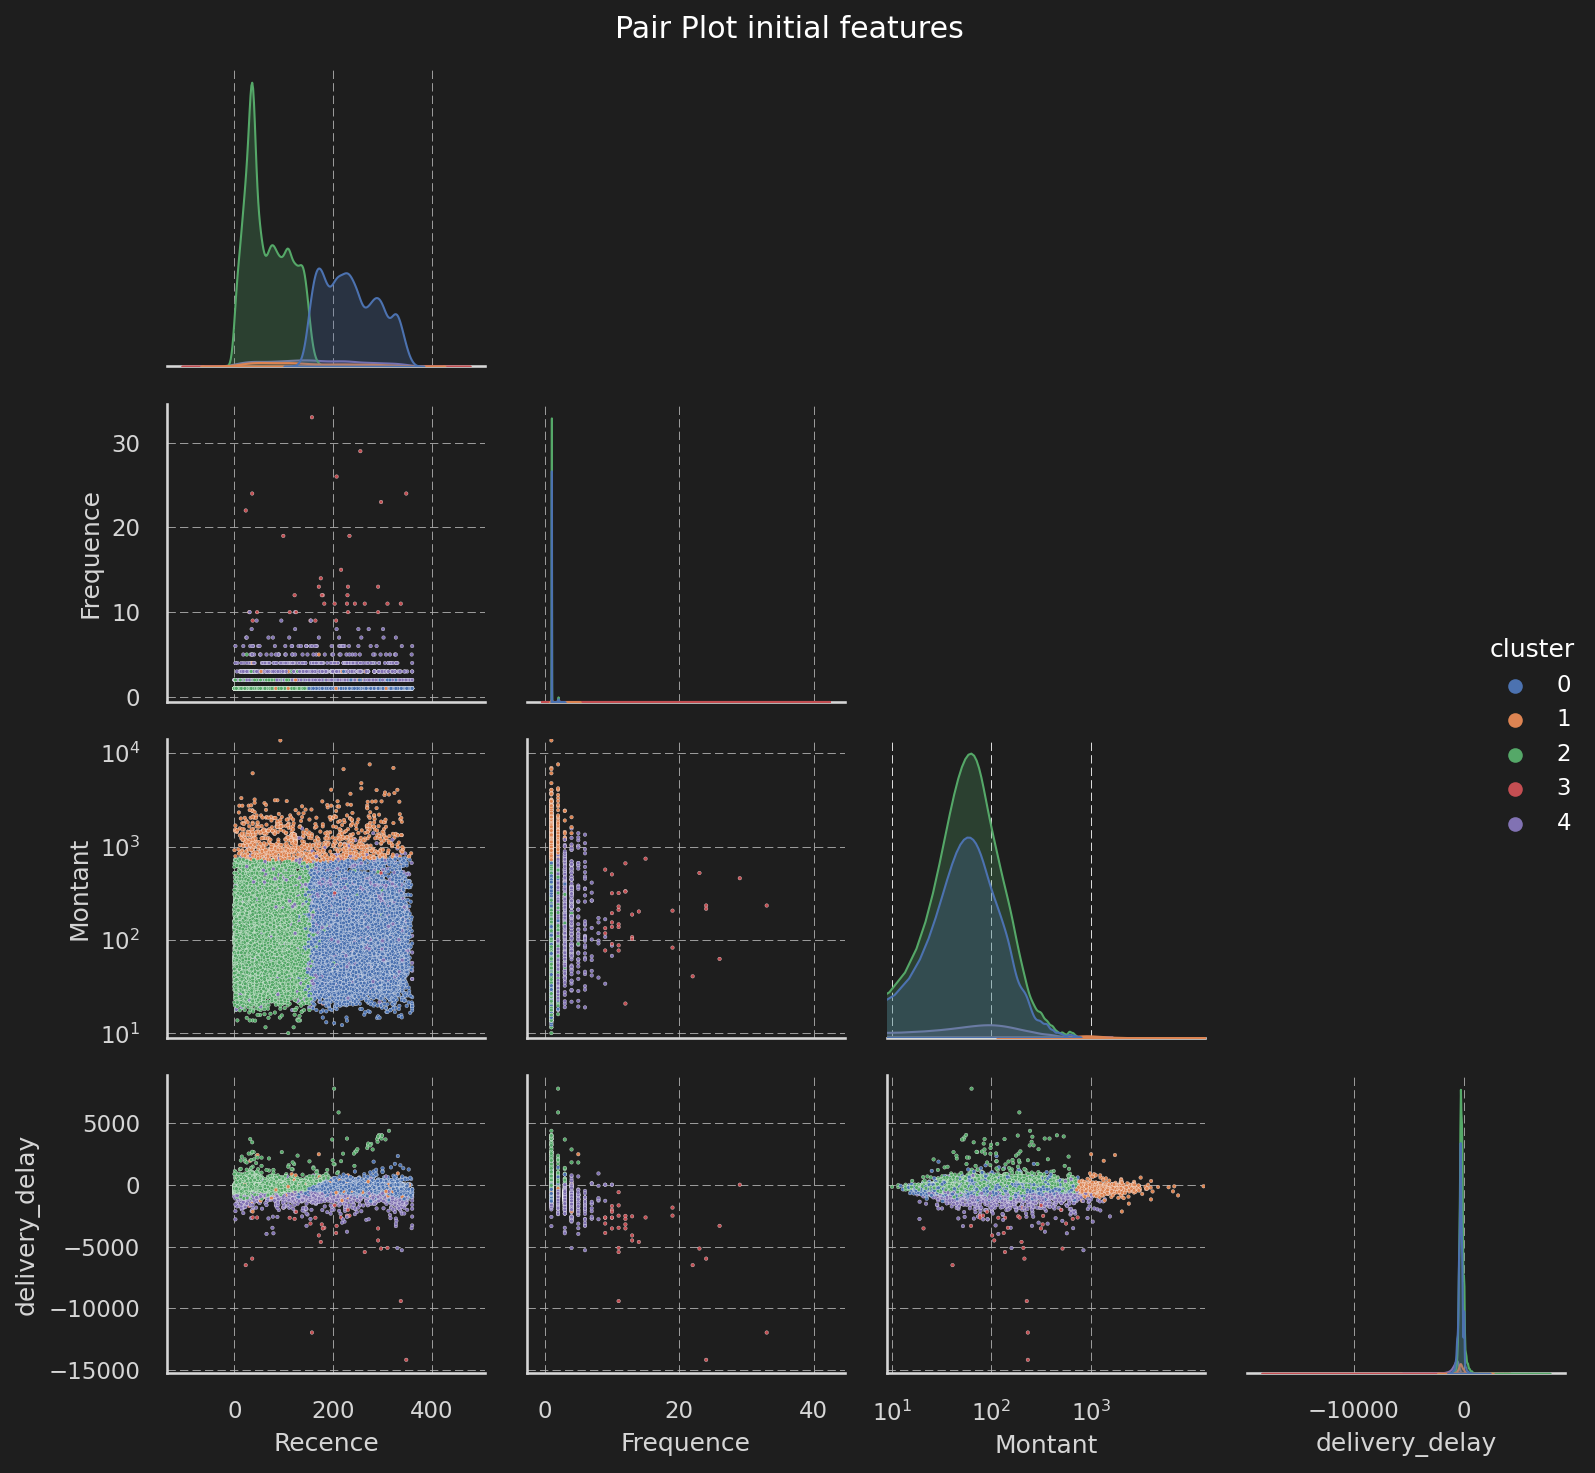

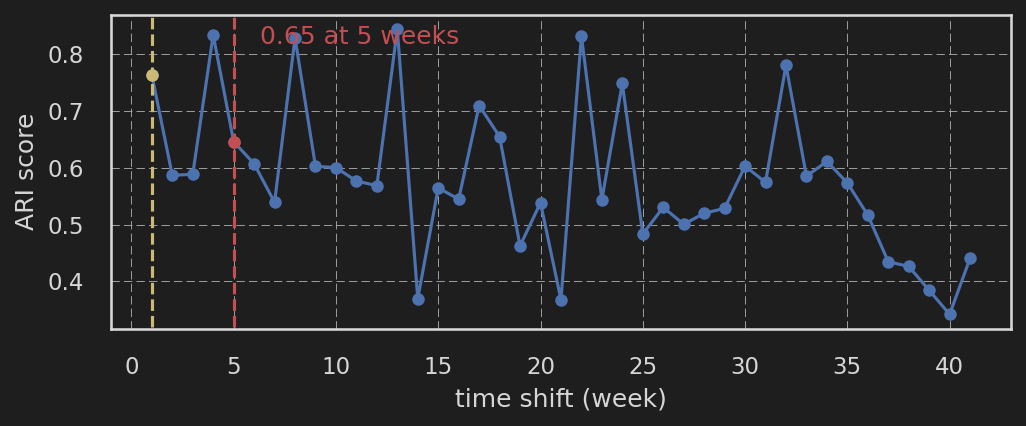

In [24]:
k = 5
compute_ARI_full(df_merged, t0, timespan, timeshift, k)

## k = 4

,Recence,Frequence,Montant,delivery_delay,count,count (%)
0,234.630000,1.100000,138.440000,-361.540000,17816,40.760000
1,144.860000,1.180000,1189.320000,-295.850000,1200,2.750000
2,68.340000,1.050000,136.800000,-234.570000,24560,56.180000
3,173.790000,7.930000,286.970000,-2420.350000,137,0.310000




|----------------------------------------|
                 4 labels                 

                     Multivariate linear model
                                                                    
--------------------------------------------------------------------
       Intercept         Value  Num DF   Den DF     F Value   Pr > F
--------------------------------------------------------------------
          Wilks' lambda  0.0780 4.0000 43706.0000 129094.5770 0.0000
         Pillai's trace  0.9220 4.0000 43706.0000 129094.5770 0.0000
 Hotelling-Lawley trace 11.8148 4.0000 43706.0000 129094.5770 0.0000
    Roy's greatest root 11.8148 4.0000 43706.0000 129094.5770 0.0000
--------------------------------------------------------------------
                                                                    
--------------------------------------------------------------------
        cluster         Value   Num DF    Den DF    F Value   Pr > F
------------------------------------

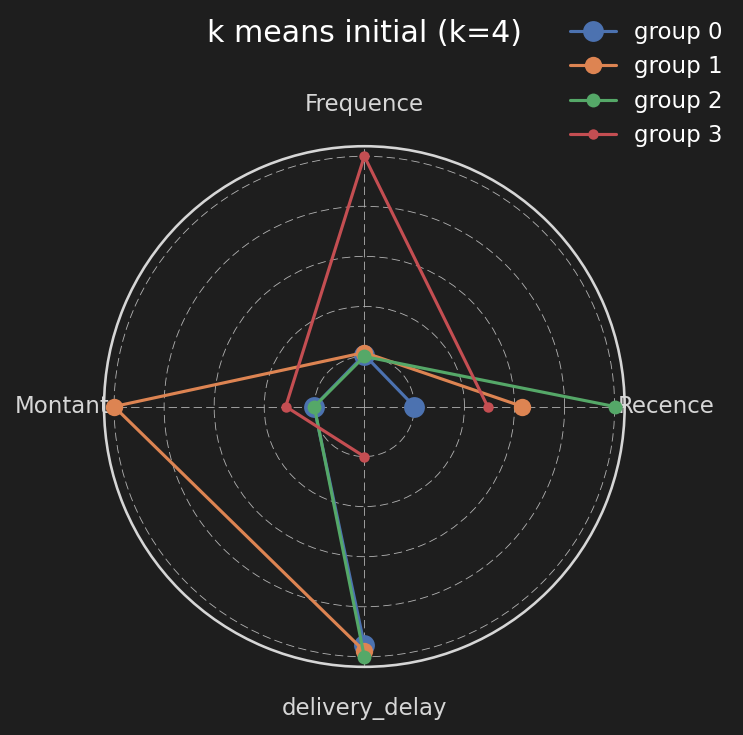

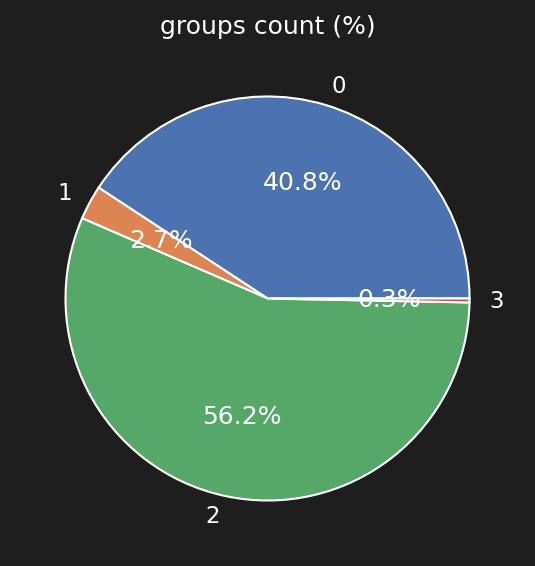

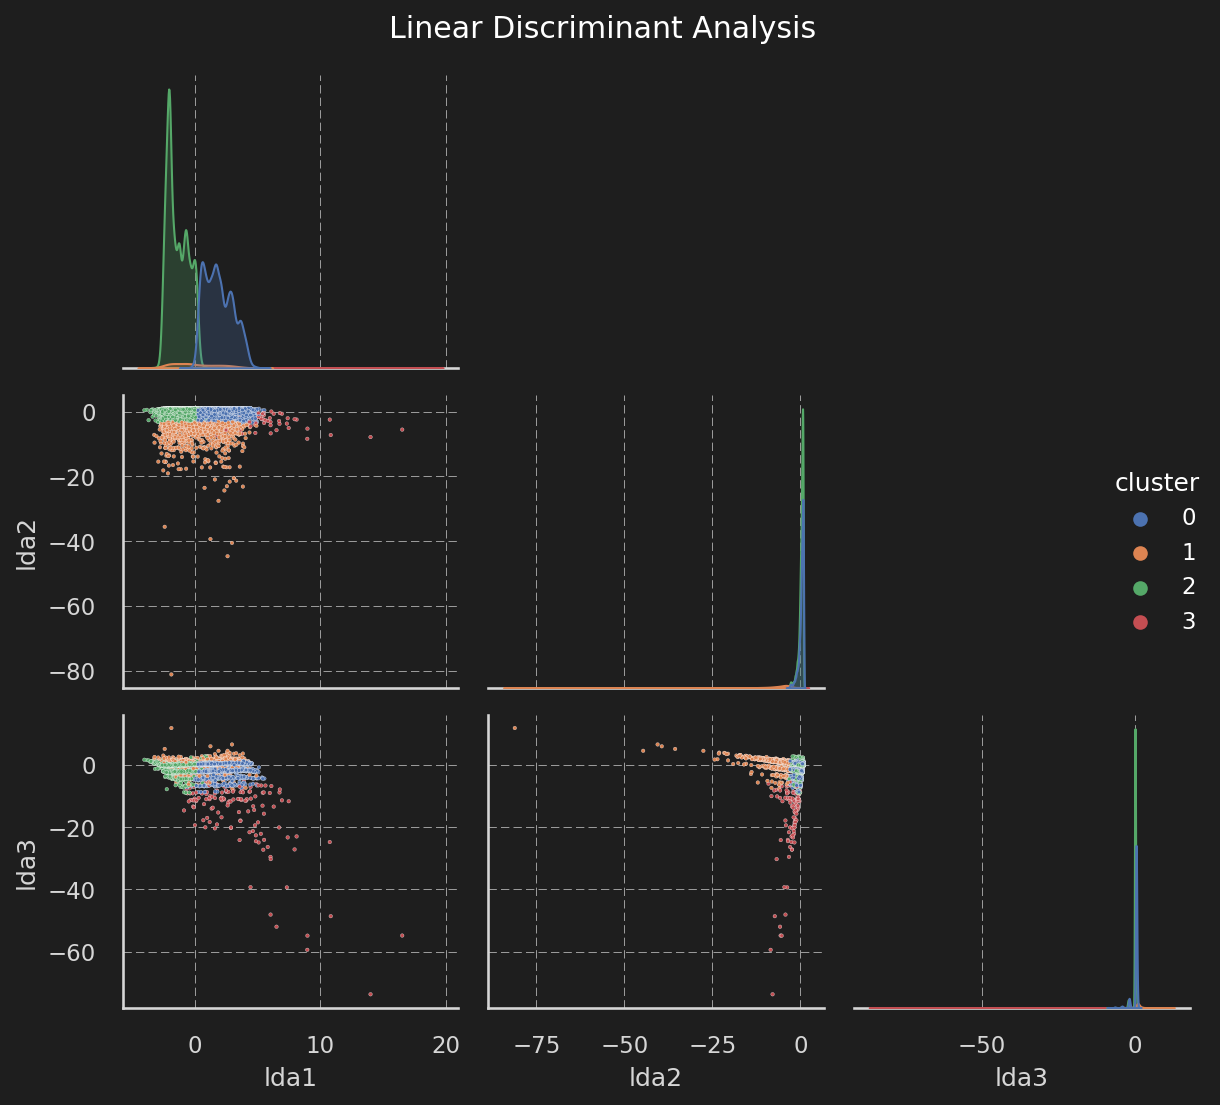

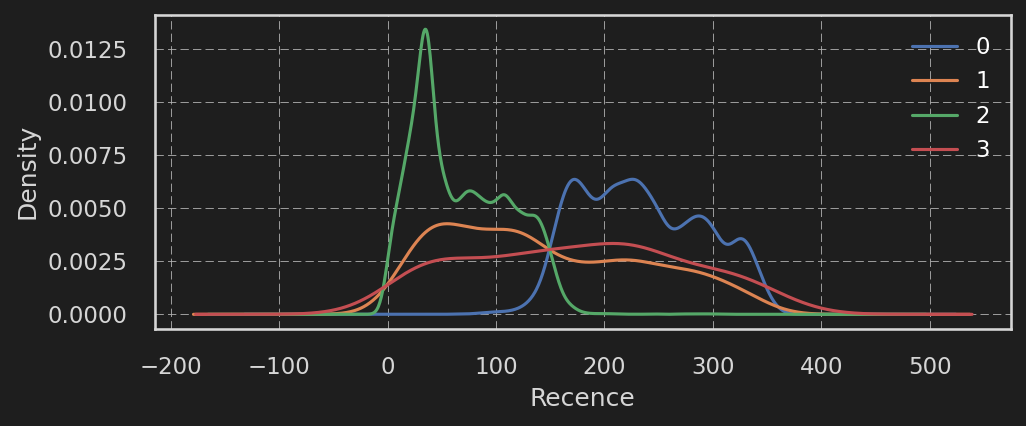

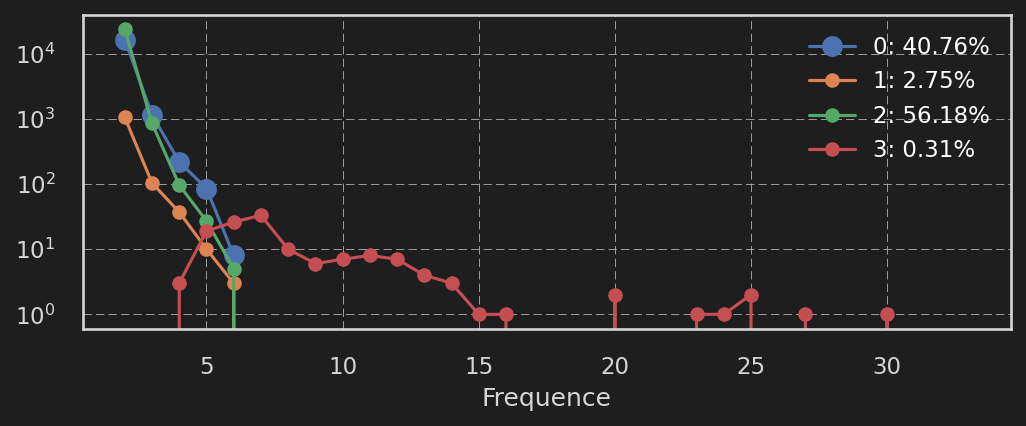

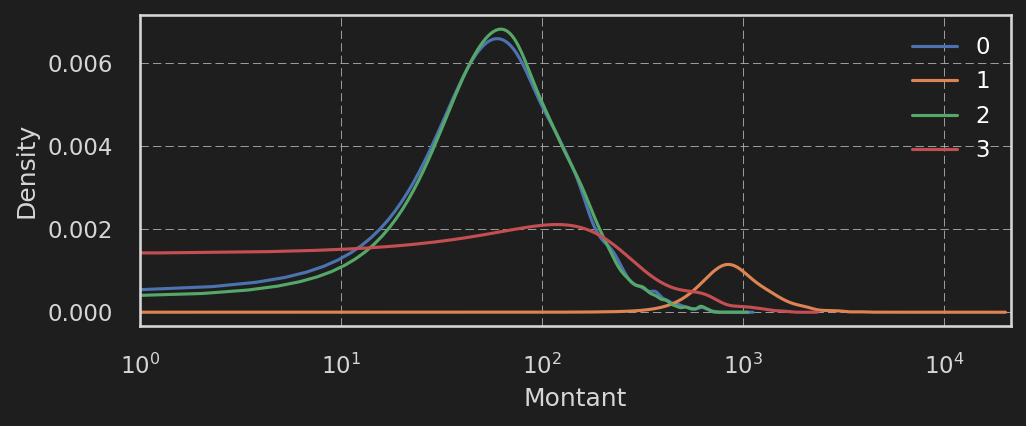

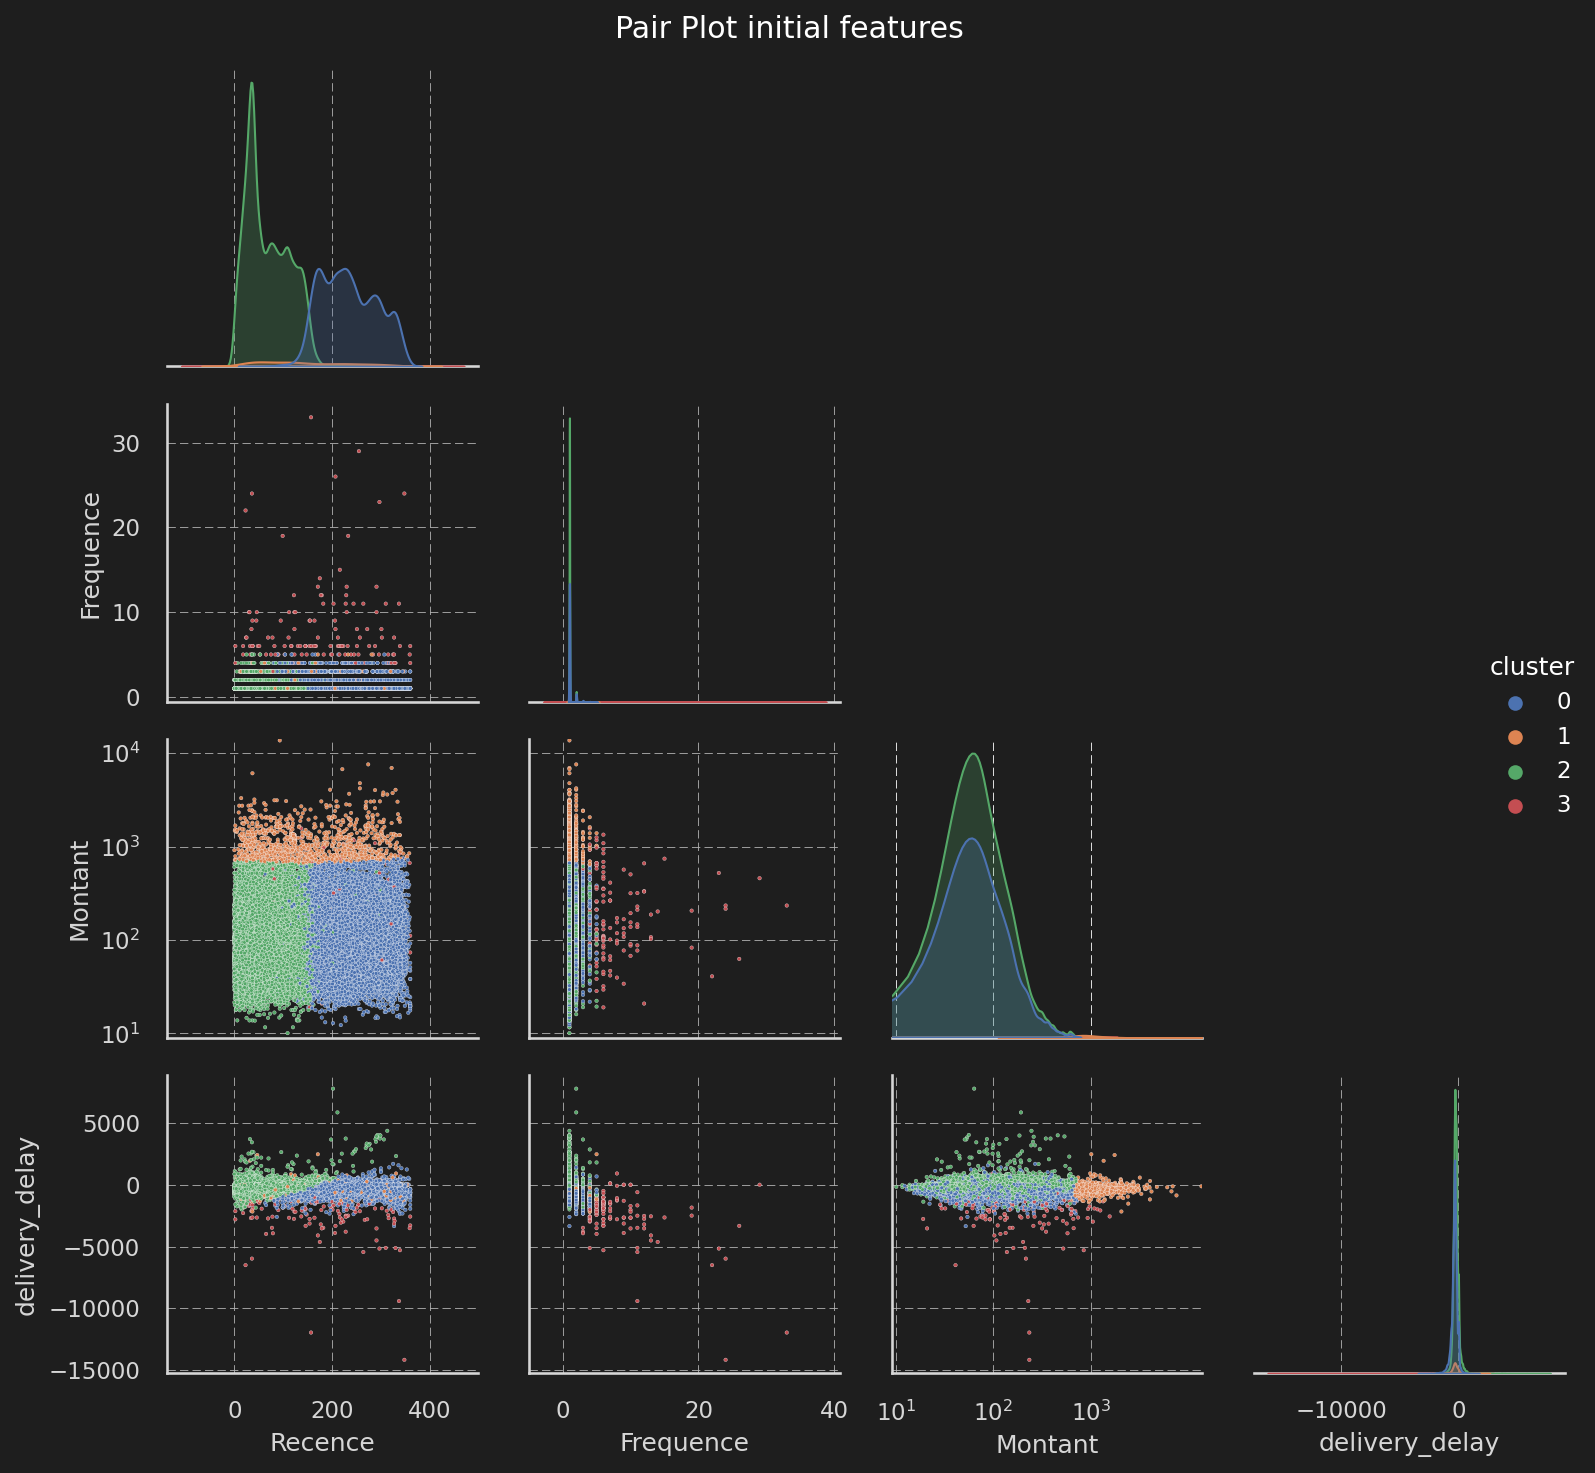

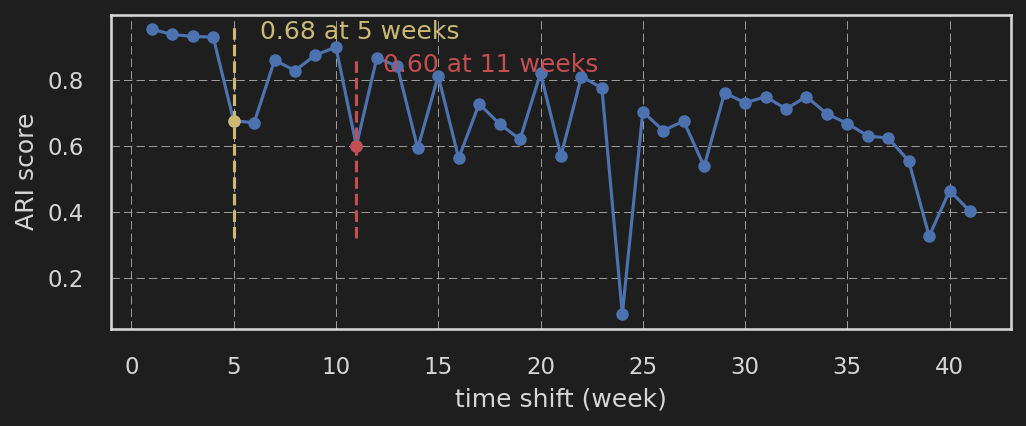

In [23]:
k = 4
compute_ARI_full( df_merged, t0, timespan, timeshift, k )

## Remarques
* Prendre 4 clusters au lieu de 5 fusionne un petit cluster (correspondant aux montants les plus élevés) avec un plus gros proche (montants élevés).
* le score ARI descend en dessous de 0.8 pour 7 / 12 semaines pour 5 clusters, et 12 / 15 semaines pour 4 clusters.